In [1]:
import  pandas  as  pd

In [2]:
df  =  pd.read_csv('data/skills.csv')

In [3]:
df.head()

,skill,category
0,communication,Soft Skill
1,python,Programming
2,collaboration,Soft Skill
3,leadership,Soft Skill
4,sql,Database


In [4]:
df['skill'].unique()

<StringArray>
[              'communication',                      'python',
               'collaboration',                  'leadership',
                         'sql',                       'agile',
            'machine learning',                         'aws',
                        'java',                       'azure',
                       'excel',                           'r',
                      'devops',                  'javascript',
                       'ci/cd',                          'go',
         'attention to detail',                       'linux',
             'problem solving',                      'docker',
                       'react',                         'git',
                    'teamwork',                  'kubernetes',
               'deep learning',                       'scrum',
                        'html',                  'creativity',
                         'css',                  'tensorflow',
                     'pytorch',          

In [5]:
# Cell 1
import re
import pandas as pd
import matplotlib.pyplot as plt

jobs = pd.read_csv("data/jobs.csv")
skills = pd.read_csv("data/skills.csv")
train = pd.read_csv("data/training_data.csv")

print("jobs:", jobs.shape)
print("skills:", skills.shape)
print("training data:", train.shape)

jobs: (500, 5)
skills: (90, 2)
training data: (1800, 5)


In [6]:
# Cell 2
print(jobs.isnull().sum())
print("Duplicate rows:", jobs.duplicated().sum())
jobs.head()

company        0
title          0
description    0
level          0
field          0
dtype: int64
Duplicate rows: 0


,company,title,description,level,field
0,Apex Systems,Data Analyst,Job#: 2025249\n\nJob Description:\n\nJob Title...,Entry level,Data Analytics
1,letsremotify,Senior Front End Developer,Job Objectives Translate customer needs into f...,Not Specified,Web Development
2,Dice,Data Scientist - TS/SCI Hybrid,Dice is the leading career destination for tec...,Entry level,Data Science
3,Zyxware Technologies,Data Science Analyst - Full Time,Role: Data Science Analyst Type: Full-Time Job...,Mid-Senior level,Data Science
4,Altos Labs,"Platform Engineer, Lab Informatics",Our Mission\n\nOur mission is to restore cell ...,Mid-Senior level,DevOps


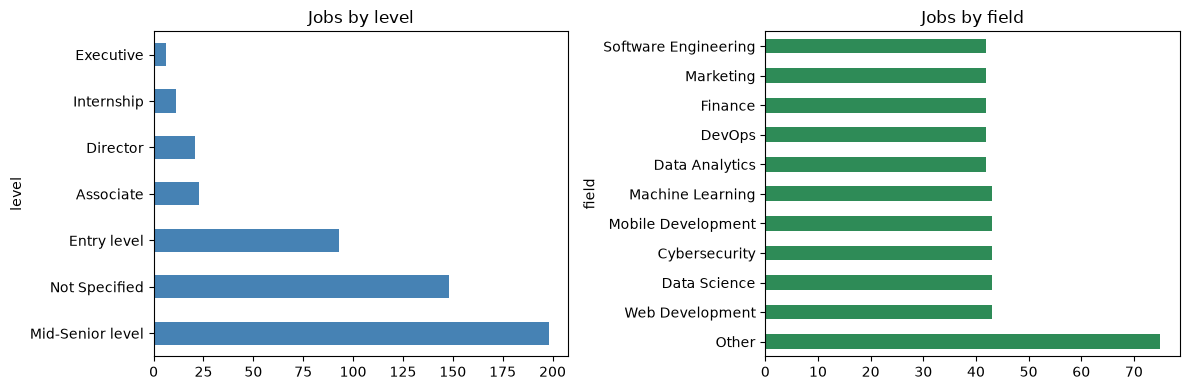

In [7]:
# Cell 3
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
jobs["level"].value_counts().plot(kind="barh", ax=ax[0], color="steelblue", title="Jobs by level")
jobs["field"].value_counts().plot(kind="barh", ax=ax[1], color="seagreen", title="Jobs by field")
plt.tight_layout()
plt.show()


count     500.000000
mean      498.450000
std       297.657998
min        11.000000
25%       257.750000
50%       470.500000
75%       684.000000
max      1581.000000
Name: words, dtype: float64


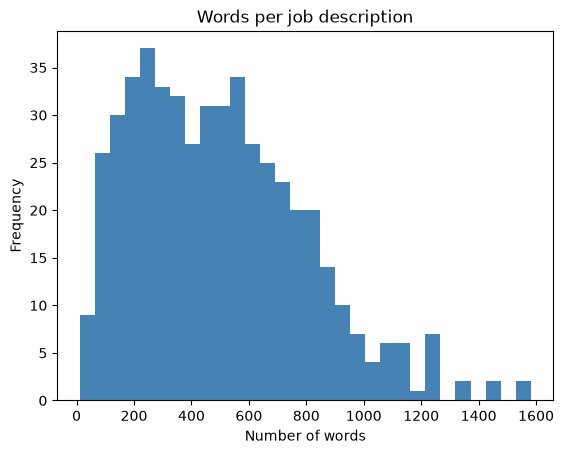

In [8]:
# Cell 4
jobs["words"] = jobs["description"].str.split().str.len()
print(jobs["words"].describe())

jobs["words"].plot(kind="hist", bins=30, color="steelblue", title="Words per job description")
plt.xlabel("Number of words")
plt.show()

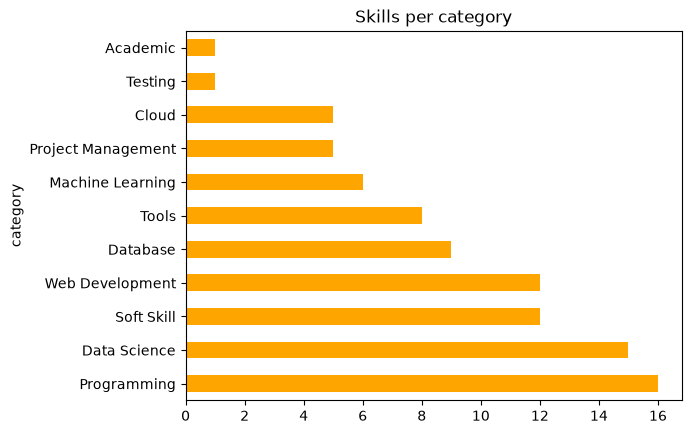

In [9]:
# Cell 5
skills["category"].value_counts().plot(kind="barh", color="orange", title="Skills per category")
plt.show()

communication       239
python              134
collaboration       120
leadership          105
research            103
sql                  90
agile                87
machine learning     80
aws                  73
java                 67
azure                66
excel                65
r                    54
data analysis        52
devops               52
dtype: int64


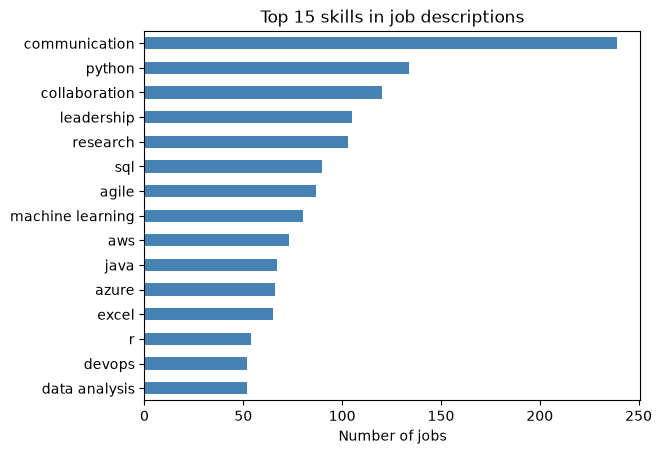

In [10]:
# Cell 6
text = jobs["description"].str.lower()

counts = {}
for skill in skills["skill"].str.lower():
    pattern = r"(?<![a-z0-9])" + re.escape(skill) + r"(?![a-z0-9])"
    counts[skill] = text.str.contains(pattern, regex=True).sum()

skill_counts = pd.Series(counts).sort_values(ascending=False)
print(skill_counts.head(15))

skill_counts.head(15).sort_values().plot(kind="barh", color="steelblue", title="Top 15 skills in job descriptions")
plt.xlabel("Number of jobs")
plt.show()

label
Needs Work    619
Not Ready     604
Good Fit      577
Name: count, dtype: int64


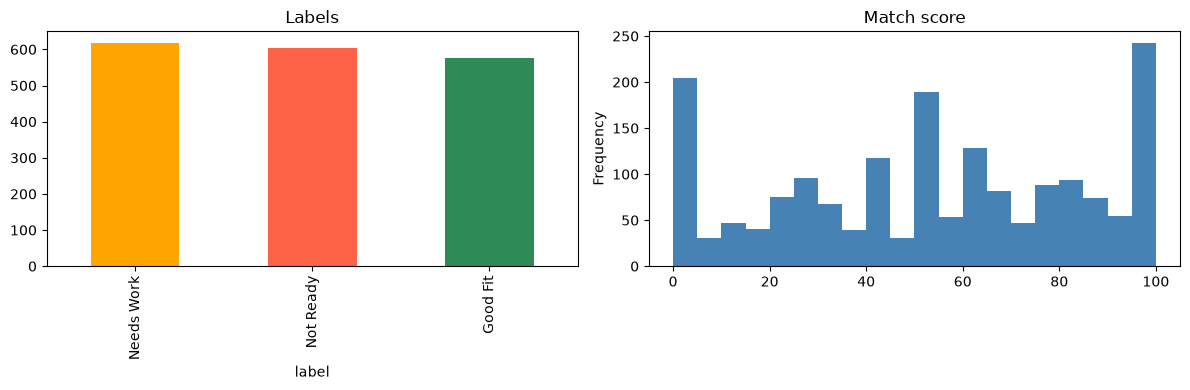

In [11]:
# Cell 7
print(train["label"].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
train["label"].value_counts().plot(kind="bar", ax=ax[0], color=["orange", "tomato", "seagreen"], title="Labels")
train["match_score"].plot(kind="hist", bins=20, ax=ax[1], color="steelblue", title="Match score")
plt.tight_layout()
plt.show()

In [12]:
# Cell 8
print("Duplicate rows:", train.duplicated().sum(), "out of", len(train))

def rule(score):
    if score >= 70:
        return "Good Fit"
    elif score >= 40:
        return "Needs Work"
    else:
        return "Not Ready"

train["rule_label"] = train["match_score"].apply(rule)
wrong = (train["rule_label"] != train["label"]).mean() * 100
print("Labels that disagree with the score rule:", round(wrong, 1), "%")

Duplicate rows: 1412 out of 1800
Labels that disagree with the score rule: 15.0 %


{'Random Forest': 81.1, 'Logistic Regression': 82.8, 'KNN': 80.8}


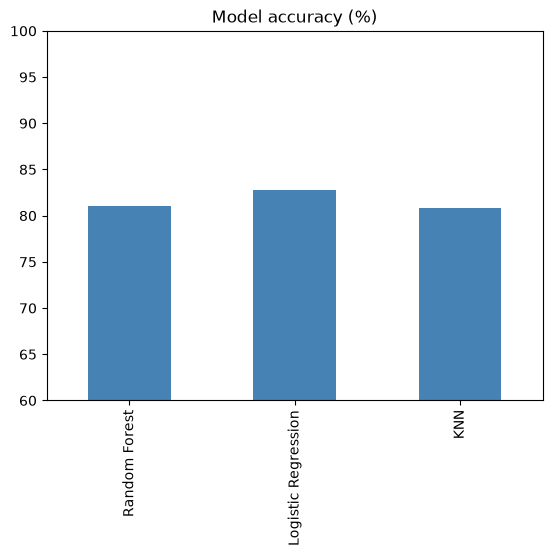

In [13]:
# Cell 9
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

X = train[["match_score", "matched_count", "missing_count", "total_required"]]
y = train["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = round(model.score(X_test, y_test) * 100, 1)

print(results)
pd.Series(results).plot(kind="bar", color="steelblue", title="Model accuracy (%)", ylim=(60, 100))
plt.show()